In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import plotly.graph_objects as go
import numpy as np
from plotly.io import write_html


In [19]:
#diff_exp_table = pd.read_csv("../results/deseq2_rsem/hydra_all_counts.tsv", sep="\t")
diff_exp_table = pd.read_csv("../results/deseq2_rsem/hydra_all_deseq2_lg2_t_to_g.tsv", sep="\t")
p_value_table = pd.read_csv("../results/deseq2_rsem/hydra_all_deseq2_pvalues_t_to_g.tsv", sep="\t")

In [20]:
p_value_table.rename(columns={"ID":"gene_id"}, inplace=True)
p_value_table.head()

,gene_id,EcoKD1_Eco1KD_B5_vs_control_B5,EcoKD1_Eco1KD_B8_vs_control_B8,HydraAHL_3OC12_vs_control,HydraAHL_3OHC12_vs_control,HydraRecolonization_Conventionalized_vs_GF,HydraRecolonization_Conventionalized_vs_Wild,HydraRecolonization_Cvbct_vs_GF,HydraRecolonization_Cvbct_vs_Wild,HydraRecolonization_GF_vs_Wild,HydraRecolonization_Wild_vs_GF,HydraTemperature_08°C_vs_18°C,HydraTemperature_12°C_vs_18°C,HydraTemperature_22°C_vs_18°C
0,HVAEP1-G011796,1.209753e-118,0.000000,2.465290e-02,5.792489e-03,0.016695,0.925976,0.009906,0.687587,0.000004,0.000004,3.952910e-116,7.106119e-108,1.617574e-04
1,HVAEP1-G011792,7.105124e-67,0.000143,9.047853e-06,3.093524e-03,0.237540,0.510849,0.336130,0.157256,0.000028,0.000028,3.524240e-20,3.575301e-21,3.673534e-10
2,HVAEP1-G008093,1.196686e-24,0.000006,4.062779e-04,3.668332e-01,0.062364,0.999464,0.223841,0.000074,0.003737,0.003737,9.010328e-12,3.125984e-15,2.941640e-01
3,HVAEP1-G028193,3.482068e-23,NaN,5.800923e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HVAEP1-G003526,2.003146e-21,0.856874,2.279078e-22,8.483718e-10,0.569012,0.919543,0.343898,0.898432,0.059384,0.059384,2.819526e-05,3.248345e-01,2.108662e-01


In [23]:
diff_exp_table.rename(columns={"ID":"gene_id"}, inplace=True)
diff_exp_table.head()

,gene_id,EcoKD1_Eco1KD_B5_vs_control_B5,EcoKD1_Eco1KD_B8_vs_control_B8,HydraAHL_3OC12_vs_control,HydraAHL_3OHC12_vs_control,HydraRecolonization_Conventionalized_vs_GF,HydraRecolonization_Conventionalized_vs_Wild,HydraRecolonization_Cvbct_vs_GF,HydraRecolonization_Cvbct_vs_Wild,HydraRecolonization_GF_vs_Wild,HydraRecolonization_Wild_vs_GF,HydraTemperature_08°C_vs_18°C,HydraTemperature_12°C_vs_18°C,HydraTemperature_22°C_vs_18°C
0,HVAEP1-G011796,-5.450531,-6.900214,0.725579,0.940945,1.559542,-0.325542,1.538879,-0.346206,-1.885084,1.885084,5.049738,4.877826,-1.159945
1,HVAEP1-G011792,-4.277718,-1.637319,3.431440,2.588356,1.724473,-1.499789,1.474066,-1.750196,-3.224262,3.224262,3.760242,3.931048,-2.995813
2,HVAEP1-G008093,-1.484129,0.652308,0.562925,0.206139,-0.445232,-0.000678,0.315489,0.760044,0.444555,-0.444555,-1.817395,-2.189243,-0.437985
3,HVAEP1-G028193,9.882394,NaN,-4.081134,-0.933282,9.301688,8.203159,-1.542223,-2.640752,-1.098530,1.098530,NaN,NaN,NaN
4,HVAEP1-G003526,-3.800719,0.240003,1.110288,0.758810,0.406119,-0.252709,0.562929,-0.095900,-0.658829,0.658829,-1.517204,-0.466975,0.631443


In [24]:
diff_exp_table["gene_id"] = diff_exp_table["gene_id"].apply(lambda x: x.split("-")[1])
p_value_table["gene_id"] = p_value_table["gene_id"].apply(lambda x: x.split("-")[1])

In [25]:
sample_description = pd.read_csv("../data/rsem_counts/sample_descriptions.csv")
sample_description.head()

,EXP,ID,sample,treatment,batch
0,HydraAHL,I27651-S1,3OC12_1,3OC12,1
1,HydraAHL,I27652-S1,3OC12_2,3OC12,1
2,HydraAHL,I27653-S1,3OC12_3,3OC12,1
3,HydraAHL,I27654-S1,3OC12_4,3OC12,1
4,HydraAHL,I27655-S1,3OC12_5,3OC12,1


In [7]:
#samples = sample_description["ID"].apply(lambda x: x+"_TPM")

In [42]:
annotation_table = pd.read_csv("../data/annotation_KO_GO.csv")

In [43]:
annotation_table.head()

,ID,KO,KO_definition,Score,Second.best,Score2,UniProtKB,KEGG.ID,KO.Number,GO.terms
0,HVAEP1.T000001.1,NaN,NaN,6.0,K21595,1.0,NaN,NaN,NaN,NaN
1,HVAEP1.T000002.1,K07188,"LIPE, HSL; hormone-sensitive lipase [EC:3.1.1.79]",171.0,NaN,NaN,P54310,LIPS_MOUSE,mmu:16890;,caveola [GO:0005901]; cytoplasm [GO:0005737]; ...
2,HVAEP1.T000003.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HVAEP1.T000004.1,NaN,NaN,8.0,K10251,1.0,NaN,NaN,NaN,NaN
4,HVAEP1.T000004.2,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
wnt_genes_portal = ["HVAEP1_T001980", "HVAEP1_T001985", "HVAEP1_T003934", "HVAEP1_T005251", "HVAEP1_T009462", "HVAEP1_T010730", 
             "HVAEP1_T010776", "HVAEP1_T010792", "HVAEP1_T011290", "HVAEP1_T011553", "HVAEP1_T011641", "HVAEP1_T013231",
             "HVAEP1_T016743", "HVAEP1_T021814", "HVAEP1_T021819", "HVAEP1_T021820", "HVAEP1_T022460", "HVAEP1_T022678",
             "HVAEP1_T023071", "HVAEP1_T023618", "HVAEP1_T023882", "HVAEP1_T028556"]

frizzled_genes_portal = ["HVAEP1_T003380","HVAEP1_T003966","HVAEP1_T005729", "HVAEP1_T009158", "HVAEP1_T011153", 
                  "HVAEP1_T011318", "HVAEP1_T024230", "HVAEP1_T024233"]
wnt_genes = []
for wnt in wnt_genes_portal:
    wnt = wnt.split("_")[1].replace("T","G")
    wnt_genes.append(wnt)

frizzled_genes = []
for frizzle in frizzled_genes_portal:
    frizzle = frizzle.split("_")[1].replace("T","G")
    frizzled_genes.append(frizzle)

In [44]:
go_annot = annotation_table[annotation_table["GO.terms"].isna() == False]
go_annot["gene_id"] = go_annot["ID"].apply(lambda x: x.split(".")[1].replace("T","G"))

#wnt_genes = go_annot[go_annot["GO.terms"].str.contains("wnt")]
#frizzled_genes = go_annot[go_annot["GO.terms"].str.contains("frizzled")]

/blast/miniconda3/lib/python3.8/site-packages/pandas/core/frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)


In [13]:
len(frizzled_genes), len(wnt_genes)

(8, 22)

In [15]:
#columns_to_extract = ["gene_id"]
#for col in diff_exp_table.columns:
#    if "TPM" in col:
#        columns_to_extract.append(col)
#tpm_table = diff_exp_table[columns_to_extract]
#tpm_table["gene_id"] = tpm_table["gene_id"].apply(lambda x: x.split(".")[1])
#tpm_table = diff_exp_table
#tpm_table.head()

In [10]:
#wnt_genes_to_tpm = wnt_genes.merge(tpm_table, on="gene_id")[columns_to_extract[1:]]
#frizzled_genes_to_tpm = frizzled_genes.merge(tpm_table, on="gene_id")[columns_to_extract[1:]]

In [46]:
wnt_genes_to_tpm = diff_exp_table[diff_exp_table["gene_id"].isin(wnt_genes)]
frizzled_genes_to_tpm = diff_exp_table[diff_exp_table["gene_id"].isin(frizzled_genes)]

wnt_genes_to_pval = p_value_table[p_value_table["gene_id"].isin(wnt_genes)]
frizzled_genes_to_pval = p_value_table[p_value_table["gene_id"].isin(frizzled_genes)]

annotation_genes_to_wnt = go_annot[go_annot["gene_id"].isin(wnt_genes)]
annotation_genes_to_frizzled = go_annot[go_annot["gene_id"].isin(frizzled_genes)]

In [47]:
annotation_genes_to_wnt.head()

,ID,KO,KO_definition,Score,Second.best,Score2,UniProtKB,KEGG.ID,KO.Number,GO.terms,gene_id
2458,HVAEP1.T001980.1,K01384,WNT11; wingless-type MMTV integration site fam...,80.0,K00408,24.0,P49337,WNT4_CHICK,gga:395561;,cytoplasm [GO:0005737]; extracellular space [G...,G001980
2463,HVAEP1.T001985.1,NaN,NaN,NaN,NaN,NaN,P49337,WNT4_CHICK,gga:395561;,cytoplasm [GO:0005737]; extracellular space [G...,G001985
6634,HVAEP3.T005251.1,K00714,WNT8; wingless-type MMTV integration site fami...,122.0,K00572,9.0,P28026,WNT8_XENLA,xla:397970;,collagen-containing extracellular matrix [GO:0...,G005251
12103,HVAEP5.T009462.1,NaN,NaN,278.0,NaN,NaN,Q9P2C4,TM181_HUMAN,hsa:57583;,membrane [GO:0016020]; toxic substance binding...,G009462
13774,HVAEP6.T010730.1,K00312,WNT3; wingless-type MMTV integration site fami...,238.0,NaN,NaN,P17553,WNT3_MOUSE,mmu:22415;,cytoplasm [GO:0005737]; endoplasmic reticulum ...,G010730


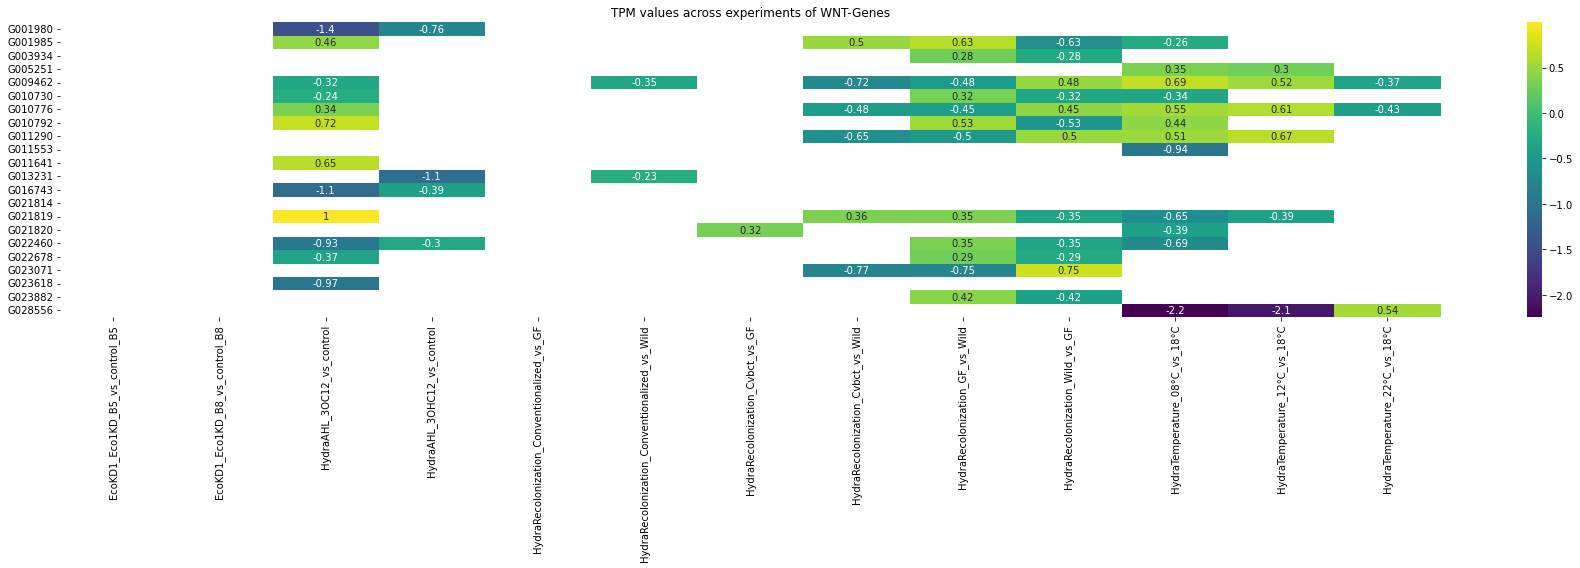

In [151]:
plt.figure(figsize=(25, 8))
custom_y_labels = wnt_genes
#sns.heatmap(wnt_genes_to_tpm.iloc[:,1:], annot=True, cmap='viridis', annot_kws={"fontsize":6}, yticklabels=custom_y_labels)

mask_matrix = wnt_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix

# Apply the mask to the heatmap
sns.heatmap(wnt_genes_to_tpm.iloc[:,1:], annot=True, cmap="viridis", mask=mask_matrix, yticklabels=custom_y_labels)

#plt.xlabel('X Values')
#plt.ylabel('Categories')
plt.title('TPM values across experiments of WNT-Genes')
#plt.show()
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/wnt_log2_heatmap.jpg")

In [152]:
annot_mat = np.repeat(annotation_genes_to_wnt["KO_definition"].to_numpy()[np.newaxis, :], len(annotation_genes_to_wnt["KO_definition"]), axis=0).T
custom_yticklabels = wnt_genes
custom_xticklabels = list(wnt_genes_to_tpm.iloc[:,1:].columns)

matrix = wnt_genes_to_tpm.iloc[:,1:].to_numpy()
mask_matrix = wnt_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
mask_matrix = mask_matrix.to_numpy()
masked_matrix = np.where(mask_matrix, np.nan, matrix)

# Create text to display above hovering cells
hover_text = list(annot_mat)#annotation_genes_to_wnt["KO_definition"].to_numpy() * 12#[['Value: {}'.format(value) for value in row] for row in wnt_genes_to_tpm.iloc[:,1:].to_numpy()]

# Create a heatmap trace

heatmap_masked = go.Heatmap(z=masked_matrix, hovertext=hover_text, hoverinfo='text', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create a heatmap trace for the original matrix (to show the unmasked areas)
heatmap_original = go.Heatmap(z=matrix, visible='legendonly', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create the figure
fig = go.Figure(data=[heatmap_masked, heatmap_original])
# Create the figure

# Update layout to set axis titles and hover mode
fig.update_layout(
    title='WNT-Genes Log2FoldChange p-value masked array of RNA-Seq experiments',
    xaxis=dict(title='Log2FoldChange',  tickmode='array', tickvals=np.arange(len(custom_xticklabels)), ticktext=custom_xticklabels, showgrid=False, tickangle=45),
    yaxis=dict(title='Hydra Gene Identifier', tickmode='array', tickvals=np.arange(len(custom_yticklabels)), ticktext=custom_yticklabels, showgrid=False),
    hovermode='closest',
    height=800,
)

# Show the plot
#fig.show()
write_html(fig, '../results/figures/genes_tpm_heatmaps/heatmap_plot_wnt.html')

In [17]:
sample_names = [sample.split("_")[0] for sample in samples]
experiment = sample_description[sample_description["ID"].isin(sample_names) ]["treatment"]

In [18]:
sample_description

,EXP,ID,sample,treatment,batch
0,HydraAHL,I27651-S1,3OC12_1,3OC12,1
1,HydraAHL,I27652-S1,3OC12_2,3OC12,1
2,HydraAHL,I27653-S1,3OC12_3,3OC12,1
3,HydraAHL,I27654-S1,3OC12_4,3OC12,1
4,HydraAHL,I27655-S1,3OC12_5,3OC12,1
...,...,...,...,...,...
57,HydraTemperature,E05850,22°C,22°C,t
58,HydraTemperature,E05851,22°C,22°C,t
59,HydraTemperature,E05852,22°C,22°C,t
60,HydraTemperature,E05853,22°C,22°C,t


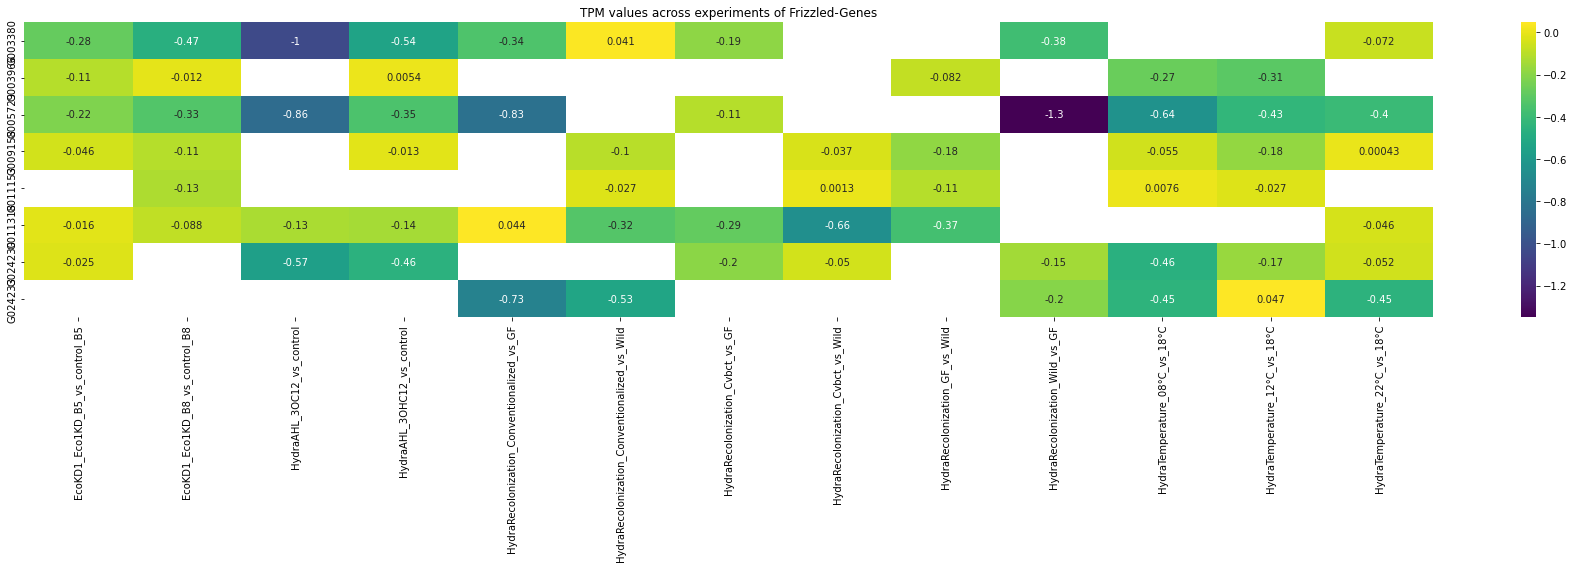

In [139]:
plt.figure(figsize=(25, 8))
custom_y_labels = frizzled_genes

mask_matrix = frizzled_genes_to_tpm.iloc[:,1:] >= 0.05  # Example mask matrix

# Apply the mask to the heatmap
sns.heatmap(frizzled_genes_to_tpm.iloc[:,1:], annot=True, cmap="viridis", mask=mask_matrix, yticklabels=custom_y_labels)
#plt.xlabel('X Values')
#plt.ylabel('Categories')
plt.title('TPM values across experiments of Frizzled-Genes')
#plt.show()
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/frizzled_log2_heatmap.jpg")

In [150]:
annot_mat = np.repeat(annotation_genes_to_frizzled["KO_definition"].to_numpy()[np.newaxis, :], len(annotation_genes_to_frizzled["KO_definition"]), axis=0).T
custom_yticklabels = frizzled_genes
custom_xticklabels = list(frizzled_genes_to_tpm.iloc[:,1:].columns)

matrix = frizzled_genes_to_tpm.iloc[:,1:].to_numpy()
mask_matrix = frizzled_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
mask_matrix = mask_matrix.to_numpy()
masked_matrix = np.where(mask_matrix, np.nan, matrix)

# Create text to display above hovering cells
hover_text = list(annot_mat)#annotation_genes_to_wnt["KO_definition"].to_numpy() * 12#[['Value: {}'.format(value) for value in row] for row in wnt_genes_to_tpm.iloc[:,1:].to_numpy()]

# Create a heatmap trace

heatmap_masked = go.Heatmap(z=masked_matrix, hovertext=hover_text, hoverinfo='text', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create a heatmap trace for the original matrix (to show the unmasked areas)
heatmap_original = go.Heatmap(z=matrix, visible='legendonly', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create the figure
fig = go.Figure(data=[heatmap_masked, heatmap_original])
# Create the figure

# Update layout to set axis titles and hover mode
fig.update_layout(
    title='Frizzled-Genes Log2FoldChange p-value masked array of RNA-Seq experiments',
    xaxis=dict(title='Log2FoldChange',  tickmode='array', tickvals=np.arange(len(custom_xticklabels)), ticktext=custom_xticklabels, showgrid=False, tickangle=45),
    yaxis=dict(title='Hydra Gene Identifier', tickmode='array', tickvals=np.arange(len(custom_yticklabels)), ticktext=custom_yticklabels, showgrid=False),
    hovermode='closest',
    height=800,
)

# Show the plot
write_html(fig, '../results/figures/genes_tpm_heatmaps/heatmap_plot_frizzled.html')
#fig.show()


In [ ]:
plt.figure(figsize=(25, 8))
sns.heatmap(frizzled_genes_to_tpm[samples], annot=True, cmap='viridis', annot_kws={"fontsize":4})
#plt.xlabel('X Values')
#plt.ylabel('Categories')
#plt.title('Heatmap of X Values by Categories')
plt.show()